# Chapter 0 — Visualizing SCF convergence

A short companion notebook to Chapter 0. We parse the reference SCF
output (`code/00-first-scf/ref/si.scf.out`) and plot how the
*estimated scf accuracy* falls each iteration — a direct picture of the
self-consistent field loop converging.

Run it after Chapter 0, or just read along. Requirements: `matplotlib`.

In [1]:
import re
from pathlib import Path

# Path to the reference SCF output (relative to this notebook).
out = Path('../code/00-first-scf/ref/si.scf.out').read_text()

# Each SCF iteration prints one 'estimated scf accuracy < ... Ry' line.
acc = [float(x) for x in re.findall(r'estimated scf accuracy\s*<\s*([0-9.eE+-]+)\s*Ry', out)]
iters = list(range(1, len(acc) + 1))
for i, a in zip(iters, acc):
    print(f'iteration {i}:  {a:.3e} Ry')

iteration 1:  5.325e-02 Ry
iteration 2:  2.439e-03 Ry
iteration 3:  4.851e-05 Ry
iteration 4:  5.300e-07 Ry
iteration 5:  2.000e-08 Ry
iteration 6:  3.600e-10 Ry


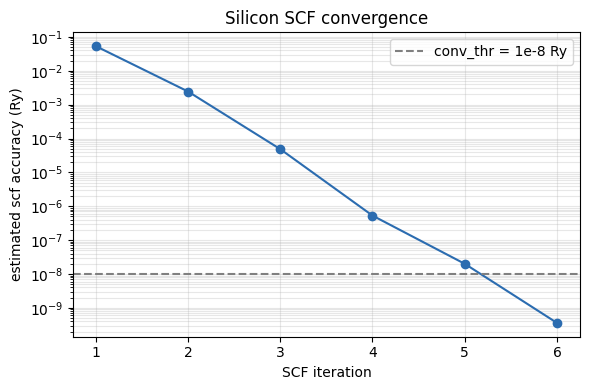

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(iters, acc, 'o-', color='#2b6cb0')
ax.axhline(1e-8, ls='--', color='gray', label='conv_thr = 1e-8 Ry')
ax.set_xlabel('SCF iteration')
ax.set_ylabel('estimated scf accuracy (Ry)')
ax.set_title('Silicon SCF convergence')
ax.set_xticks(iters)
ax.legend()
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()

# Save a copy for the website, then show inline.
out_png = Path('../static/img/00-scf-convergence.png')
out_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_png, dpi=120)
plt.show()

**What you see:** the error drops by 1–2 orders of magnitude per
iteration and crosses `conv_thr` (1e-8 Ry) at iteration 6 — at which
point QE declares convergence. That monotone funnel is the Kohn–Sham
self-consistency loop doing its job. Harder systems (metals, magnetic
materials) converge less smoothly; that's where `mixing_beta` and other
knobs from later chapters matter.